In [2]:
"""
import shutil
shutil.rmtree("CRP_dataset")
"""

'\nimport shutil\nshutil.rmtree("CRP_dataset")\n'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import shutil
shutil.copytree(
    '/content/drive/MyDrive/CRP_dataset',
    'CRP_dataset'
)

'CRP_dataset'

In [5]:
!pip install torch torchvision --upgrade
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-980phhuv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-980phhuv
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=e1102aa896bcb223b93eb1b3d0c1d963a83fd3ce14a9e36d16701b1017d353d9
  Stored in directory: /tmp/pip-ephem-wheel-cache-hx0tx37r/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [6]:
pip install time

ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import numpy as np
import random
import os
from dataload import CustomImageDataset
from model_clip import CLIPCombinedInteractModel
from sklearn.model_selection import StratifiedShuffleSplit
import time

num_classes = 4
batch_size = 32
max_epochs = 100
patience = 20
repeats = 3

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [2]:
print(sorted(os.listdir("CRP_dataset/crp_iphone/full")))

['190', '2800', '3300', '560']


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_curves(train_losses, train_accs, val_accs, seed):
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, train_losses, 'b-', label='Train Loss')
    ax1.set_title(f'Training Loss (Seed {seed})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_accs, 'b-', label='Train Acc')
    ax2.plot(epochs, val_accs,   'r-', label='Val Acc')
    ax2.set_title(f'Accuracy (Seed {seed})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'curves_seed_{seed}.png', dpi=150)
    plt.show()

def plot_confusion_matrix(all_labels, all_preds, seed, class_names=['190', '2800', '3300', '560']):
    cm = confusion_matrix(all_labels, all_preds)
    # Normalize to percentage
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'Confusion Matrix - Counts (Seed {seed})')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # Percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'Confusion Matrix - % (Seed {seed})')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_seed_{seed}.png', dpi=150)
    plt.show()

Starting load Dataset: CRP_dataset/crp_iphone/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_iphone/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images


100%|███████████████████████████████████████| 244M/244M [00:04<00:00, 58.4MiB/s]


Seed 42 Epoch 1: Loss=1.7128 | Train Acc=0.4728 | Val Acc=0.3000
Seed 42 Epoch 2: Loss=0.7778 | Train Acc=0.9205 | Val Acc=0.3000
Seed 42 Epoch 3: Loss=0.5357 | Train Acc=0.9791 | Val Acc=0.4750
Seed 42 Epoch 4: Loss=0.3940 | Train Acc=0.9874 | Val Acc=0.7125
Seed 42 Epoch 5: Loss=0.2773 | Train Acc=1.0000 | Val Acc=0.8625
Seed 42 Epoch 6: Loss=0.2604 | Train Acc=0.9916 | Val Acc=0.9250
Seed 42 Epoch 7: Loss=0.1924 | Train Acc=1.0000 | Val Acc=0.9500
Seed 42 Epoch 8: Loss=0.1857 | Train Acc=1.0000 | Val Acc=0.9500
Seed 42 Epoch 9: Loss=0.1256 | Train Acc=1.0000 | Val Acc=0.9500
Seed 42 Epoch 10: Loss=0.1350 | Train Acc=1.0000 | Val Acc=0.9625
Seed 42 Epoch 11: Loss=0.1138 | Train Acc=1.0000 | Val Acc=0.9750
Seed 42 Epoch 12: Loss=0.0830 | Train Acc=1.0000 | Val Acc=0.9750
Seed 42 Epoch 13: Loss=0.0730 | Train Acc=1.0000 | Val Acc=0.9750
Seed 42 Epoch 14: Loss=0.0770 | Train Acc=1.0000 | Val Acc=0.9750
Seed 42 Epoch 15: Loss=0.0512 | Train Acc=1.0000 | Val Acc=0.9750
Seed 42 Epoch 16: L

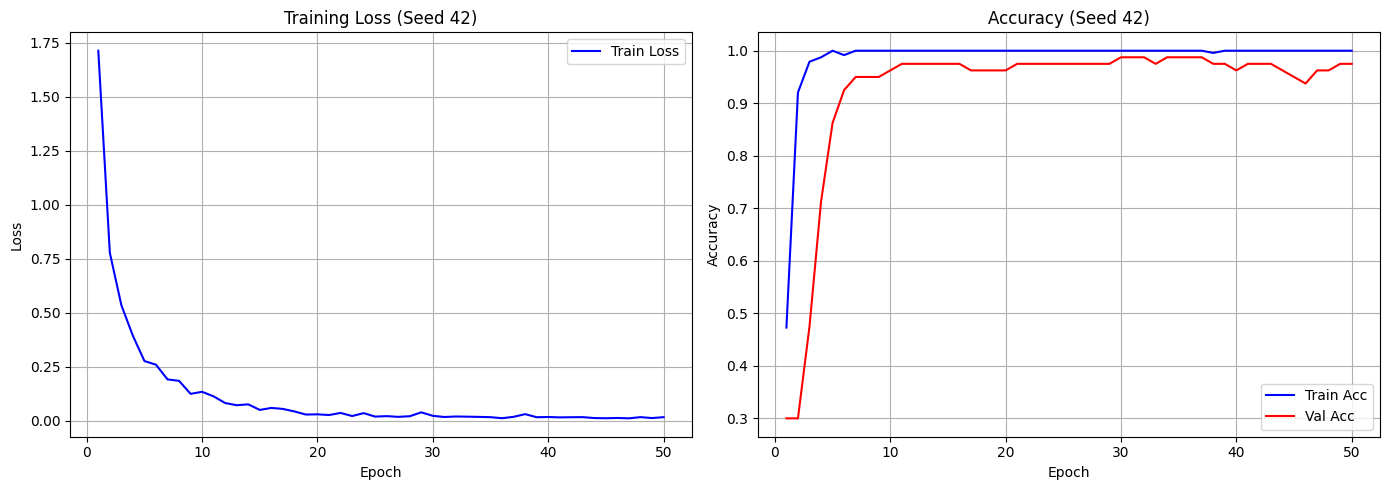

Loading best model from best_model_seed_42.pt for testing
Seed 42: Test Acc = 0.9625



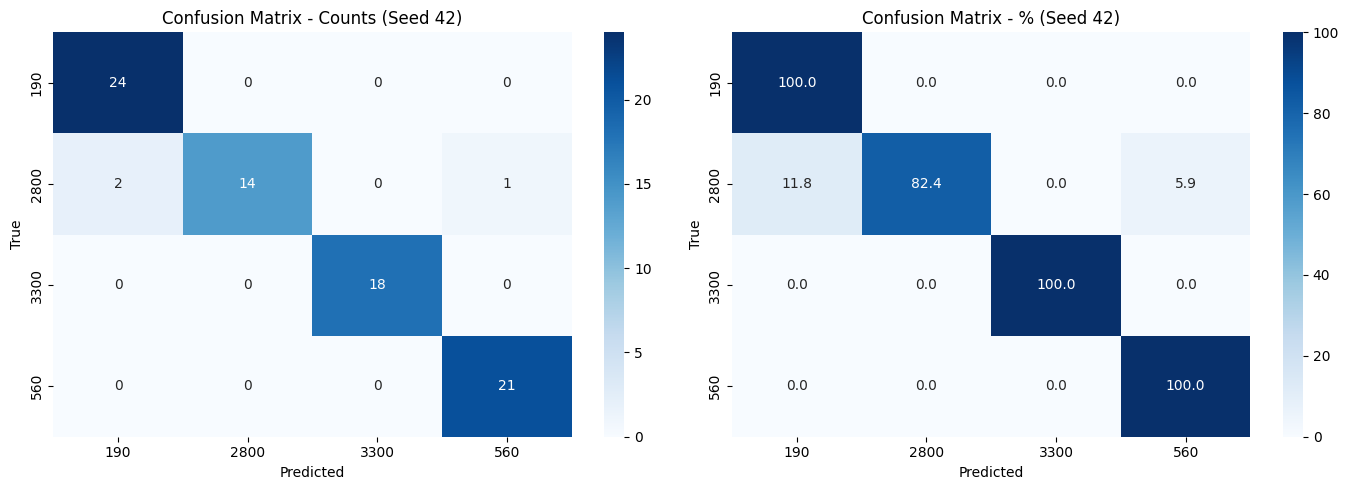

Total time: 4.45 min
Seed 142 Epoch 1: Loss=1.6716 | Train Acc=0.4393 | Val Acc=0.3250
Seed 142 Epoch 2: Loss=0.8257 | Train Acc=0.8954 | Val Acc=0.4000
Seed 142 Epoch 3: Loss=0.5567 | Train Acc=0.9540 | Val Acc=0.6000
Seed 142 Epoch 4: Loss=0.4151 | Train Acc=0.9958 | Val Acc=0.7750
Seed 142 Epoch 5: Loss=0.3389 | Train Acc=0.9958 | Val Acc=0.8125
Seed 142 Epoch 6: Loss=0.2426 | Train Acc=0.9958 | Val Acc=0.9500
Seed 142 Epoch 7: Loss=0.2028 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 8: Loss=0.1831 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 9: Loss=0.1482 | Train Acc=1.0000 | Val Acc=0.9750
Seed 142 Epoch 10: Loss=0.1262 | Train Acc=1.0000 | Val Acc=0.9500
Seed 142 Epoch 11: Loss=0.1004 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 12: Loss=0.0903 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 13: Loss=0.0948 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 14: Loss=0.0777 | Train Acc=1.0000 | Val Acc=0.9625
Seed 142 Epoch 15: Loss=0.0619 | Train Acc=1.0000 

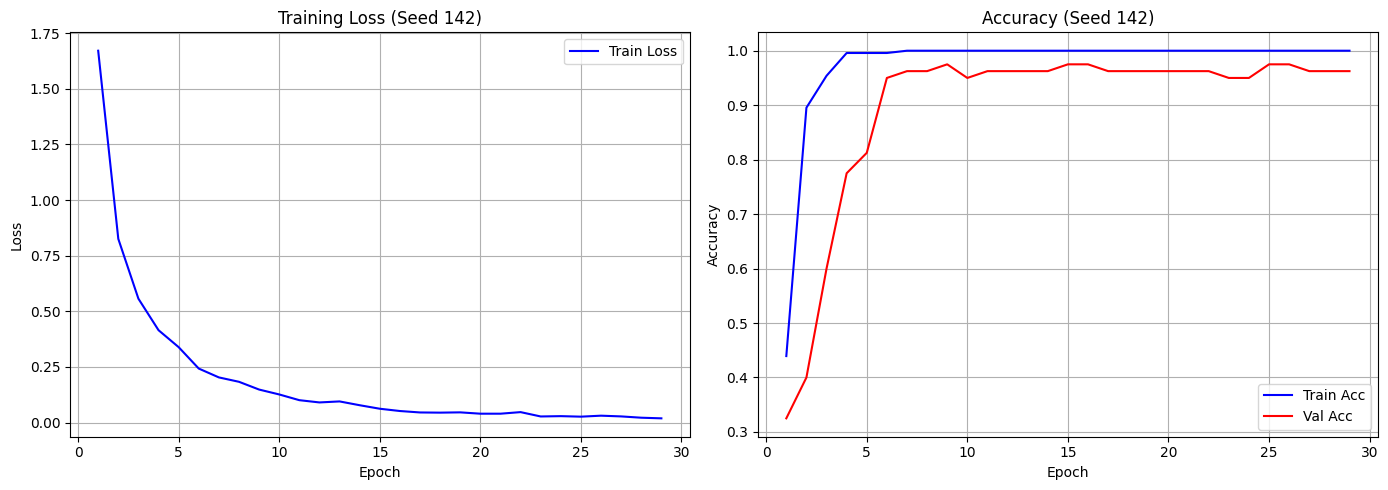

Loading best model from best_model_seed_142.pt for testing
Seed 142: Test Acc = 1.0000



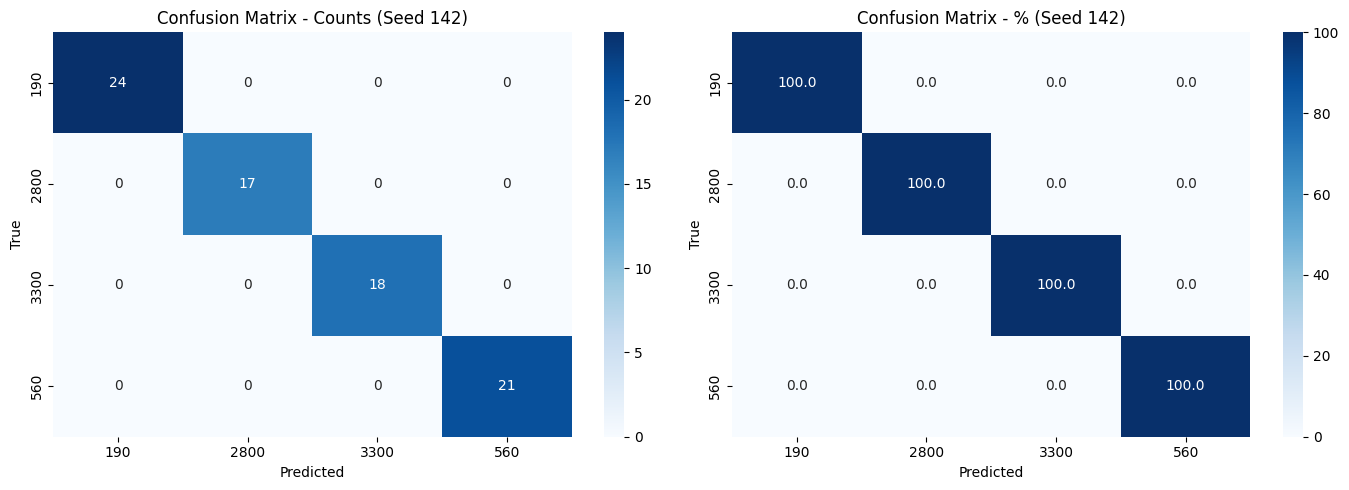

Total time: 2.82 min
Seed 242 Epoch 1: Loss=1.5759 | Train Acc=0.4854 | Val Acc=0.3875
Seed 242 Epoch 2: Loss=0.7780 | Train Acc=0.9121 | Val Acc=0.3125
Seed 242 Epoch 3: Loss=0.5720 | Train Acc=0.9498 | Val Acc=0.4250
Seed 242 Epoch 4: Loss=0.3936 | Train Acc=0.9874 | Val Acc=0.6500
Seed 242 Epoch 5: Loss=0.2845 | Train Acc=1.0000 | Val Acc=0.7500
Seed 242 Epoch 6: Loss=0.2279 | Train Acc=1.0000 | Val Acc=0.9375
Seed 242 Epoch 7: Loss=0.1931 | Train Acc=1.0000 | Val Acc=0.9500
Seed 242 Epoch 8: Loss=0.1547 | Train Acc=1.0000 | Val Acc=0.9750
Seed 242 Epoch 9: Loss=0.1576 | Train Acc=0.9958 | Val Acc=0.9625
Seed 242 Epoch 10: Loss=0.1191 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 11: Loss=0.0973 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 12: Loss=0.0764 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 13: Loss=0.0677 | Train Acc=1.0000 | Val Acc=0.9500
Seed 242 Epoch 14: Loss=0.0802 | Train Acc=1.0000 | Val Acc=0.9625
Seed 242 Epoch 15: Loss=0.0535 | Train Acc=1.0000 

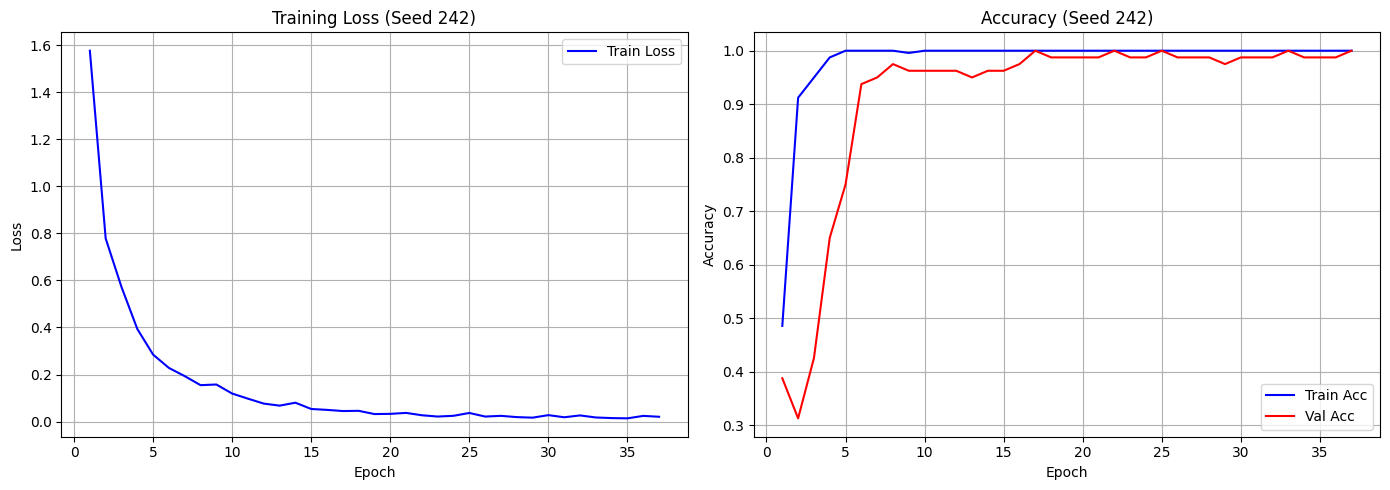

Loading best model from best_model_seed_242.pt for testing
Seed 242: Test Acc = 0.9875



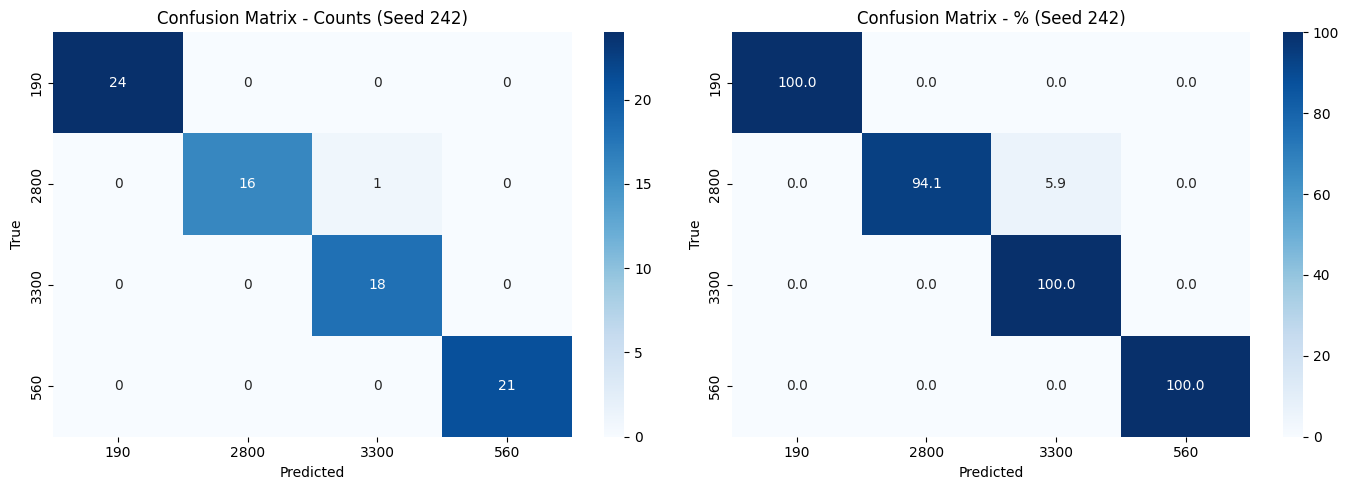

Total time: 3.50 min


In [4]:
dataset_full = CustomImageDataset("CRP_dataset/crp_iphone/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_iphone/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_iphone/white", transform=transform)
labels = [dataset_full.preprocessed_data[path]['label'] for path in dataset_full.samples]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_once(seed, dataset_full, dataset_black, dataset_white, labels):
    seed_everything(seed)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=seed)
    for train_idx, test_val_idx in sss.split(np.zeros(len(labels)), labels):
        temp_labels = [labels[i] for i in test_val_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        for val_idx_rel, test_idx_rel in sss_val.split(np.zeros(len(temp_labels)), temp_labels):
            val_idx = [test_val_idx[i] for i in val_idx_rel]
            test_idx = [test_val_idx[i] for i in test_idx_rel]

    train_full = Subset(dataset_full, train_idx)
    val_full = Subset(dataset_full, val_idx)
    test_full = Subset(dataset_full, test_idx)

    train_black = Subset(dataset_black, train_idx)
    val_black = Subset(dataset_black, val_idx)
    test_black = Subset(dataset_black, test_idx)

    train_white = Subset(dataset_white, train_idx)
    val_white = Subset(dataset_white, val_idx)
    test_white = Subset(dataset_white, test_idx)

    train_loader = DataLoader(list(zip(train_full, train_black, train_white)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(list(zip(val_full, val_black, val_white)), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(list(zip(test_full, test_black, test_white)), batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CLIPCombinedInteractModel(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)


    best_acc = 0
    counter = 0
    best_model_path = f"best_model_seed_{seed}.pt"
    train_losses, train_accs, val_accs = [], [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss   = 0
        train_correct = 0
        train_total   = 0

        for batch in train_loader:
            (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
            optimizer.zero_grad()
            outputs, aux_f, aux_b, aux_w = model(full_img.to(device), black_img.to(device), white_img.to(device))
            label = label.to(device)
            loss = criterion(outputs, label) \
                + 0.1 * criterion(aux_f, label) \
                + 0.1 * criterion(aux_b, label) \
                + 0.1 * criterion(aux_w, label)
            loss.backward()
            optimizer.step()

            epoch_loss    += loss.item()
            _, predicted   = torch.max(outputs.data, 1)
            train_total   += label.size(0)
            train_correct += (predicted == label.to(device)).sum().item()

        scheduler.step()

        avg_loss  = epoch_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_loss)
        train_accs.append(train_acc)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
                outputs, _, _, _ = model(full_img.to(device), black_img.to(device), white_img.to(device))
                _, predicted = torch.max(outputs.data, 1)
                total += label.size(0)
                correct += (predicted == label.to(device)).sum().item()

        val_acc = correct / total
        val_accs.append(val_acc)
        print(f"Seed {seed} Epoch {epoch+1}: Loss={avg_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} with best val acc {best_acc:.4f}")
            break

    plot_curves(train_losses, train_accs, val_accs, seed)

    print(f"Loading best model from {best_model_path} for testing")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    all_preds  = []
    all_labels = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in test_loader:
            (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
            outputs, _, _, _ = model(full_img.to(device), black_img.to(device), white_img.to(device))
            _, predicted = torch.max(outputs.data, 1)
            total += label.size(0)
            correct += (predicted == label.to(device)).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(label.numpy())

    test_acc = correct / total
    print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")
    plot_confusion_matrix(all_labels, all_preds, seed)

for repeat in range(repeats):
    seed = 42 + repeat * 100
    start = time.time()
    train_once(seed, dataset_full, dataset_black, dataset_white, labels)
    end = time.time()
    print(f"Total time: {(end-start)/60:.2f} min")


In [5]:
from PIL import Image
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPCombinedInteractModel(num_classes=4).to(device)
model.load_state_dict(torch.load('best_model_seed_242.pt'))
model.eval()

# in paths ko apni actual images se replace karo
full_img  = transform(Image.open("CRP_dataset/crp_iphone/full/3300/1.JPG").convert("RGB")).unsqueeze(0).to(device)
black_img = transform(Image.open("CRP_dataset/crp_iphone/black/3300/1_0_crop.jpg").convert("RGB")).unsqueeze(0).to(device)
white_img = transform(Image.open("CRP_dataset/crp_iphone/white/3300/-1_1.jpg").convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    outputs, _, _, _ = model(full_img, black_img, white_img)
    probs = torch.softmax(outputs, dim=1).squeeze().tolist()
    pred = torch.argmax(outputs).item()

print("Predicted:", pred, "→", ["190","2800","3300","560"][pred])
print("Probs:", [f"{p*100:.1f}%" for p in probs])

Predicted: 2 → 3300
Probs: ['0.2%', '0.2%', '99.1%', '0.6%']


Testing on different augmentations/filters (simulating images from diff devices)

In [6]:
import os
from PIL import Image, ImageEnhance
import numpy as np
from multiprocessing import Pool

def simulate_xiaomi(img):
    img = img.convert('RGB')
    r, g, b = img.split()
    r = ImageEnhance.Brightness(r).enhance(1.1)
    b = ImageEnhance.Brightness(b).enhance(0.85)
    img = Image.merge('RGB', (r, g, b))
    img = ImageEnhance.Sharpness(img).enhance(1.8)
    img = ImageEnhance.Brightness(img).enhance(1.05)
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 8, img_array.shape)
    img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img_array)

def simulate_vivo(img):
    img = img.convert('RGB')
    r, g, b = img.split()
    r = ImageEnhance.Brightness(r).enhance(0.9)
    b = ImageEnhance.Brightness(b).enhance(1.15)
    img = Image.merge('RGB', (r, g, b))
    img = ImageEnhance.Sharpness(img).enhance(0.6)
    img = ImageEnhance.Contrast(img).enhance(1.1)
    img = ImageEnhance.Brightness(img).enhance(0.95)
    img_array = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 3, img_array.shape)
    img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img_array)

def process_single_image(args):
    in_path, out_path, device = args
    img = Image.open(in_path)
    if device == "xiaomi":
        aug = simulate_xiaomi(img)
    elif device == "vivo":
        aug = simulate_vivo(img)
    aug.save(out_path)

def augment_dataset(input_root, output_root, device_name, num_workers=4):
    backgrounds = ['black', 'full', 'white']
    classes = ['190', '560', '2800', '3300']

    # Saari tasks pehle collect karo
    tasks = []
    for bg in backgrounds:
        for cls in classes:
            in_dir  = os.path.join(input_root, bg, cls)
            out_dir = os.path.join(output_root, bg, cls)
            os.makedirs(out_dir, exist_ok=True)

            for fname in os.listdir(in_dir):
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                tasks.append((
                    os.path.join(in_dir, fname),
                    os.path.join(out_dir, fname),
                    device_name
                ))

    print(f"{device_name}: {len(tasks)} images...")

    with Pool(num_workers) as p:
        for i, _ in enumerate(p.imap(process_single_image, tasks)):
            print(f"{i+1}/{len(tasks)}", end='\r')  # same line update

    print(f"\n{device_name} done!")

# Run
start = time.time()
augment_dataset("CRP_dataset/crp_iphone", "CRP_dataset/crp_xiaomi", "xiaomi", num_workers=2)
augment_dataset("CRP_dataset/crp_iphone", "CRP_dataset/crp_vivo",   "vivo",   num_workers=2)
end = time.time()
print(f"Total time: {(end-start)/60:.2f} min")

xiaomi: 1197 images...

xiaomi done!
vivo: 1197 images...
1197/1197
vivo done!
Total time: 25.13 min


Starting load Dataset: CRP_dataset/crp_vivo/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_vivo/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_vivo/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Loading best model from best_model_seed_242.pt for testing


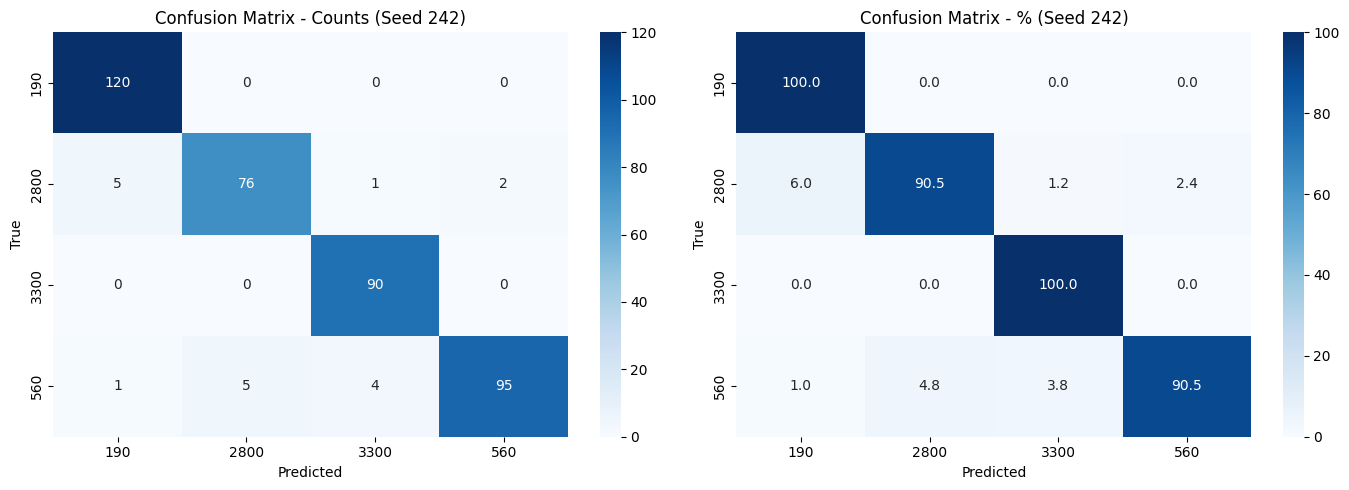

Seed 242: Test Acc = 0.9549

Total time: 0.26 min


In [13]:
dataset_full = CustomImageDataset("CRP_dataset/crp_vivo/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_vivo/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_vivo/white", transform=transform)

# change acc to best model saved
seed = 242
test_loader = DataLoader(list(zip(dataset_full, dataset_black, dataset_white)), batch_size=batch_size, shuffle=False)

print(f"Loading best model from best_model_seed_{seed}.pt for testing")
start = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPCombinedInteractModel(num_classes=4).to(device)
model.load_state_dict(torch.load('best_model_seed_242.pt'))
model.eval()

all_preds  = []
all_labels = []
correct = 0
total   = 0
with torch.no_grad():
    for batch in test_loader:
        (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
        outputs, _, _, _ = model(full_img.to(device), black_img.to(device), white_img.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label.to(device)).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.numpy())

plot_confusion_matrix(all_labels, all_preds, seed)

test_acc = correct / total
print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")
end = time.time()
print(f"Total time: {(end-start)/60:.2f} min")

Starting load Dataset: CRP_dataset/crp_xiaomi/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/black
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Starting load Dataset: CRP_dataset/crp_xiaomi/white
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Loading best model from best_model_seed_242.pt for testing


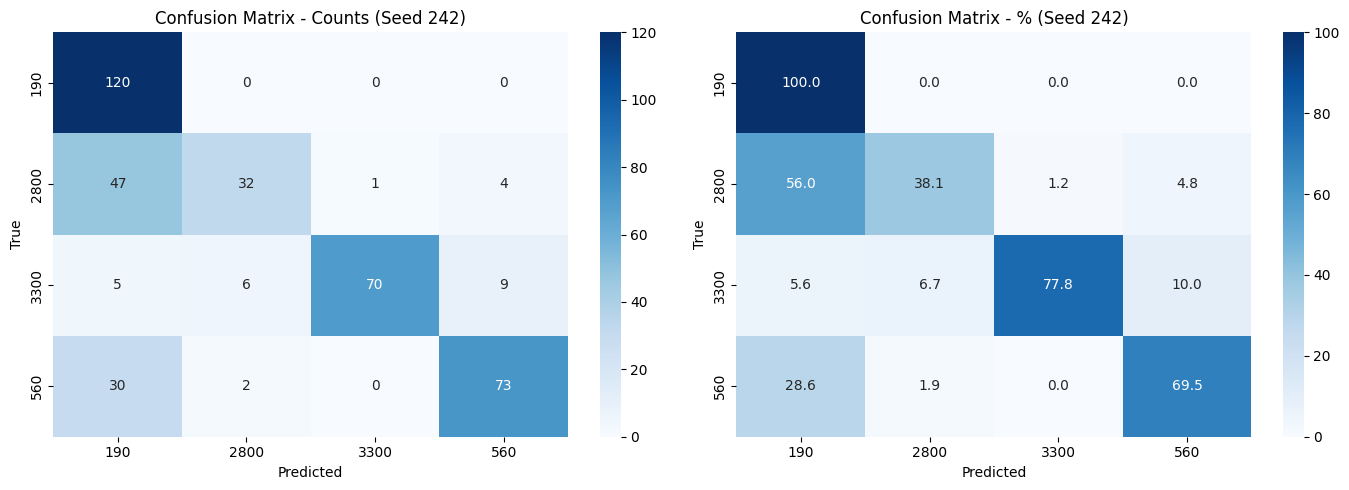

Seed 242: Test Acc = 0.7393

Total time: 0.27 min


In [16]:
dataset_full = CustomImageDataset("CRP_dataset/crp_xiaomi/full", transform=transform)
dataset_black = CustomImageDataset("CRP_dataset/crp_xiaomi/black", transform=transform)
dataset_white = CustomImageDataset("CRP_dataset/crp_xiaomi/white", transform=transform)

test_loader = DataLoader(list(zip(dataset_full, dataset_black, dataset_white)), batch_size=batch_size, shuffle=False)

print(f"Loading best model from best_model_seed_{seed}.pt for testing")
start = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CLIPCombinedInteractModel(num_classes=4).to(device)
model.load_state_dict(torch.load('best_model_seed_242.pt'))
model.eval()

all_preds  = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        (full_img, label, _), (black_img, _, _), (white_img, _, _) = batch
        outputs, _, _, _ = model(full_img.to(device), black_img.to(device), white_img.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += label.size(0)
        correct += (predicted == label.to(device)).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.numpy())

plot_confusion_matrix(all_labels, all_preds, seed)

test_acc = correct / total
print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")
end = time.time()
print(f"Total time: {(end-start)/60:.2f} min")

In [ ]:
"""import shutil
from google.colab import files
shutil.make_archive("CRP_dataset", "zip", "CRP_dataset")
files.download("CRP_dataset.zip")"""

In [ ]:
from google.colab import files
files.download("best_model_seed_142.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>